# Notebook 3 — Self-Diffusion Coefficient from MSD Analysis

This notebook loads the trajectories produced by **Notebook 1** (GAFF2) and
**Notebook 2** (MACE-OFF23), computes the **mean-squared displacement (MSD)**
using MDAnalysis, and extracts the **self-diffusion coefficient** $D$ of
liquid ethanol at 298.15 K.

## Theory

The Einstein relation connects the MSD of particles to the self-diffusion
coefficient:

$$\text{MSD}(\tau) = \langle |\mathbf{r}(t+\tau) - \mathbf{r}(t)|^2 \rangle
                    \xrightarrow{\tau \to \infty} 2dD\tau$$

where $d$ is the spatial dimensionality (3 for bulk liquid) and $D$ is the
self-diffusion coefficient.  In practice we:

1. Compute the MSD as a function of lag time $\tau$
2. Identify the **linear (diffusive) regime** on a log-log plot (slope ≈ 1)
3. Fit a straight line: $\text{MSD} = 2dD\,\tau + c$
4. Extract $D = \text{slope} / (2d)$

### Experimental reference

The experimental self-diffusion coefficient of pure ethanol at 25 °C is approximately **$D_{\text{exp}} \approx 1.06 \times 10^{-9}$ m²/s**
(Pratt & Wakeham, *J. Chem. Soc. Faraday Trans. 2*, 1977).

## 0. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

import MDAnalysis as mda
from MDAnalysis.analysis.msd import EinsteinMSD

print(f"MDAnalysis version: {mda.__version__}")

MDAnalysis version: 2.10.0


## 1. Configuration

Define the file paths and physical parameters.

In [2]:
GAFF2_TOPOLOGY = "gaff2_topology.pdb"
GAFF2_TRAJECTORY = "gaff2_production.dcd"

MACE_TOPOLOGY = "mace_topology.pdb"
MACE_TRAJECTORY = "mace_production.dcd"

D_EXPERIMENTAL = 1.06e-9  # m^2/s at 25 °C
DIM = 3                   # 3D diffusion

## 2. Helper function — compute MSD

We wrap the MDAnalysis `EinsteinMSD` calculation in a reusable function.

In [3]:
def compute_msd(topology_file, trajectory_file, select="all", fft=True):
    """Compute the MSD using MDAnalysis EinsteinMSD.

    Returns
    -------
    lagtimes : np.ndarray
        Lag times in picoseconds.
    msd : np.ndarray
        Mean-squared displacement in Angstrom^2.
    dt : float
        Frame interval in picoseconds.
    """
    u = mda.Universe(topology_file, trajectory_file)
    print(f"  Loaded: {u.trajectory.n_frames} frames, {u.atoms.n_atoms} atoms")
    print(f"  Timestep between frames: {u.trajectory.dt:.4f} ps")

    msd_analysis = EinsteinMSD(u, select=select, msd_type="xyz", fft=fft)
    msd_analysis.run(verbose=True)

    msd = msd_analysis.results.timeseries       # Angstrom^2
    n_frames = msd_analysis.n_frames
    dt = u.trajectory.dt                         # ps
    lagtimes = np.arange(n_frames) * dt          # ps

    return lagtimes, msd, dt

## 3. Compute MSD for both force fields

In [4]:
print("=== GAFF2 ===")
lag_gaff2, msd_gaff2, dt_gaff2 = compute_msd(GAFF2_TOPOLOGY, GAFF2_TRAJECTORY)

print("\n=== MACE-OFF23 ===")
lag_mace, msd_mace, dt_mace = compute_msd(MACE_TOPOLOGY, MACE_TRAJECTORY)

=== GAFF2 ===
  Loaded: 2000 frames, 1800 atoms
  Timestep between frames: 1.0000 ps


/home/howziin/micromamba/envs/md-demo/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 1800/1800 [00:00<00:00, 1806.85it/s]



=== MACE-OFF23 ===
  Loaded: 400 frames, 1800 atoms
  Timestep between frames: 0.5000 ps


  0%|          | 0/400 [00:00<?, ?it/s]

100%|██████████| 1800/1800 [00:00<00:00, 5204.16it/s]


## 4. Plot MSD vs. lag time

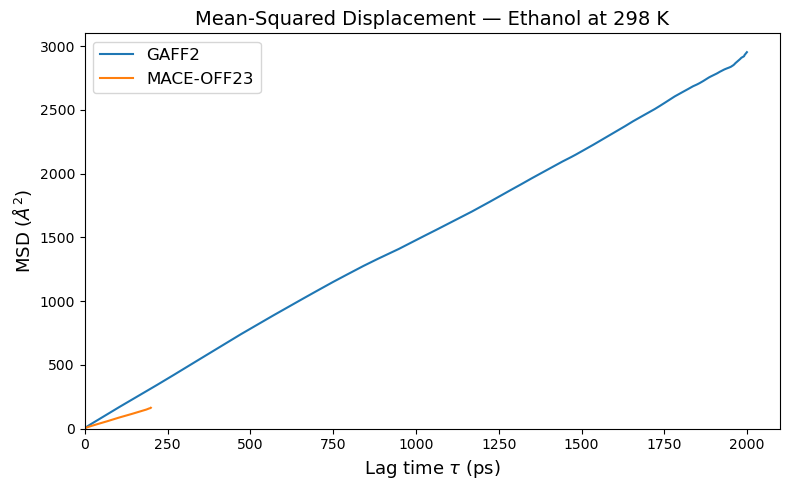

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(lag_gaff2, msd_gaff2, label="GAFF2", lw=1.5)
ax.plot(lag_mace, msd_mace, label="MACE-OFF23", lw=1.5)

ax.set_xlabel(r"Lag time $\tau$ (ps)", fontsize=13)
ax.set_ylabel(r"MSD ($\AA^2$)", fontsize=13)
ax.set_title("Mean-Squared Displacement — Ethanol at 298 K", fontsize=14)
ax.legend(fontsize=12)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig("msd_linear.png", dpi=150)
plt.show()

## 5. Fit the linear regime and extract D

We select the **middle portion** of the MSD curve (20%–80% of the total
lag time) for the linear fit.  The early part contains ballistic motion
and the late part has poor statistics.

$$D = \frac{\text{slope}}{2d}$$

where $d = 3$ and the slope has units of $\text{\AA}^2/\text{ps}$.

Unit conversion: $1\;\text{\AA}^2/\text{ps} = 10^{-8}\;\text{m}^2/\text{s} \cdot 10^{12}\;\text{s/ps}^{-1}$
... actually $1\;\text{\AA}^2/\text{ps} = 10^{-20}\;\text{m}^2 \;/\; 10^{-12}\;\text{s} = 10^{-8}\;\text{m}^2/\text{s}$.

In [7]:
A2_PER_PS_TO_M2_PER_S = 1e-8  # 1 Å²/ps = 1e-8 m²/s


def fit_diffusion(lagtimes, msd, dim=3, fit_start_frac=0.2, fit_end_frac=0.8):
    """Fit the linear regime of the MSD to extract D.

    Parameters
    ----------
    lagtimes : array, ps
    msd : array, Å²
    dim : int
        Spatial dimensionality (3 for xyz).
    fit_start_frac, fit_end_frac : float
        Fraction of total lag-time range to use for fitting.

    Returns
    -------
    D : float
        Self-diffusion coefficient in m²/s.
    slope : float
        Slope in Å²/ps.
    intercept : float
        Intercept in Å².
    r_value : float
        Pearson R of the fit.
    i_start, i_end : int
        Index range used for fitting.
    """
    n = len(lagtimes)
    i_start = int(n * fit_start_frac)
    i_end = int(n * fit_end_frac)
    i_start = max(i_start, 1)  # avoid tau=0

    result = linregress(lagtimes[i_start:i_end], msd[i_start:i_end])
    slope = result.slope          # Å²/ps
    intercept = result.intercept  # Å²
    r_value = result.rvalue

    D = (slope / (2 * dim)) * A2_PER_PS_TO_M2_PER_S  # m²/s

    return D, slope, intercept, r_value, i_start, i_end

In [11]:
D_gaff2, slope_g, intercept_g, r_g, i0_g, i1_g = fit_diffusion(lag_gaff2, msd_gaff2)
D_mace, slope_m, intercept_m, r_m, i0_m, i1_m = fit_diffusion(lag_mace, msd_mace)

print("=" * 60)
print(f"{'Method':<15} {'D (m²/s)':<20} {'slope (Å²/ps)':<18} {'R²':<10}")
print("-" * 60)
print(f"{'GAFF2':<15} {D_gaff2:<20.4e} {slope_g:<18.4f} {r_g**2:<10.6f}")
print(f"{'MACE-OFF23':<15} {D_mace:<20.4e} {slope_m:<18.4f} {r_m**2:<10.6f}")
print(f"{'Experiment':<15} {D_EXPERIMENTAL:<20.4e}")
print("=" * 60)

Method          D (m²/s)             slope (Å²/ps)      R²        
------------------------------------------------------------
GAFF2           2.3027e-09           1.3816             0.999638  
MACE-OFF23      1.2865e-09           0.7719             0.999755  
Experiment      1.0600e-09          


## 6. Visualize the fits

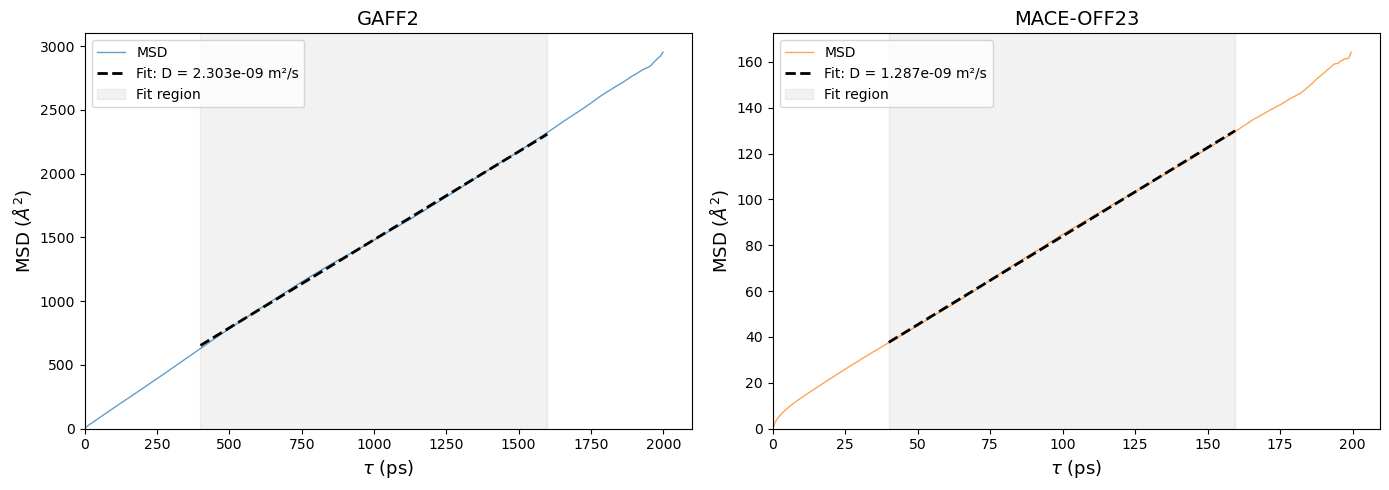

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# --- GAFF2 ---
ax = axes[0]
ax.plot(lag_gaff2, msd_gaff2, "C0", lw=1, alpha=0.7, label="MSD")
fit_tau_g = lag_gaff2[i0_g:i1_g]
ax.plot(fit_tau_g, slope_g * fit_tau_g + intercept_g, "k--", lw=2,
        label=f"Fit: D = {D_gaff2:.3e} m²/s")
ax.axvspan(lag_gaff2[i0_g], lag_gaff2[i1_g - 1], alpha=0.1, color="gray",
           label="Fit region")
ax.set_xlabel(r"$\tau$ (ps)", fontsize=13)
ax.set_ylabel(r"MSD ($\AA^2$)", fontsize=13)
ax.set_title("GAFF2", fontsize=14)
ax.legend(fontsize=10)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# --- MACE ---
ax = axes[1]
ax.plot(lag_mace, msd_mace, "C1", lw=1, alpha=0.7, label="MSD")
fit_tau_m = lag_mace[i0_m:i1_m]
ax.plot(fit_tau_m, slope_m * fit_tau_m + intercept_m, "k--", lw=2,
        label=f"Fit: D = {D_mace:.3e} m²/s")
ax.axvspan(lag_mace[i0_m], lag_mace[i1_m - 1], alpha=0.1, color="gray",
           label="Fit region")
ax.set_xlabel(r"$\tau$ (ps)", fontsize=13)
ax.set_ylabel(r"MSD ($\AA^2$)", fontsize=13)
ax.set_title("MACE-OFF23", fontsize=14)
ax.legend(fontsize=10)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("msd_fits.png", dpi=150)
plt.show()

## 7. Bar chart comparison

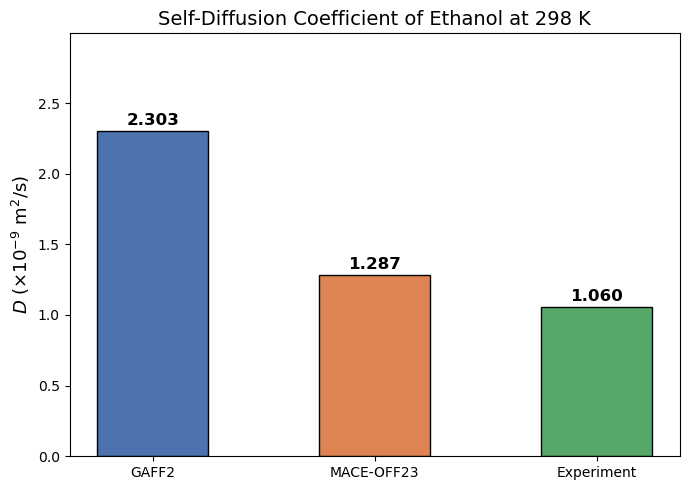


GAFF2      : D = 2.3027e-09 m²/s  (217.2% of expt.)
MACE-OFF23 : D = 1.2865e-09 m²/s  (121.4% of expt.)
Experiment : D = 1.0600e-09 m²/s


In [10]:
methods = ["GAFF2", "MACE-OFF23", "Experiment"]
D_values = np.array([D_gaff2, D_mace, D_EXPERIMENTAL]) * 1e9  # convert to 10^-9 m²/s
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(methods, D_values, color=colors, edgecolor="black", width=0.5)

for bar, val in zip(bars, D_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylabel(r"$D$ ($\times 10^{-9}$ m$^2$/s)", fontsize=13)
ax.set_title("Self-Diffusion Coefficient of Ethanol at 298 K", fontsize=14)
ax.set_ylim(0, max(D_values) * 1.3)
plt.tight_layout()
plt.savefig("diffusion_comparison.png", dpi=150)
plt.show()

print(f"\nGAFF2      : D = {D_gaff2:.4e} m²/s  ({D_gaff2/D_EXPERIMENTAL*100:.1f}% of expt.)")
print(f"MACE-OFF23 : D = {D_mace:.4e} m²/s  ({D_mace/D_EXPERIMENTAL*100:.1f}% of expt.)")
print(f"Experiment : D = {D_EXPERIMENTAL:.4e} m²/s")

## 8. Discussion

### What to look for in your results

- **GAFF2** is a classical, empirically parameterized force field.  It
  typically reproduces liquid densities well but may over- or under-predict
  the diffusion coefficient by 10–30%, depending on the molecule and the
  charge model (AM1-BCC vs. RESP).

- **MACE-OFF23** is a machine-learned potential trained on DFT data.  It
  captures polarization and many-body effects that classical force fields
  miss.  However, the shorter trajectory length may lead to larger
  statistical uncertainty in the MSD fit.

- The **experimental value** of $D \approx 1.06 \times 10^{-9}$ m$^2$/s
  serves as the ground truth.

## Summary

| Output file | Description |
|---|---|
| `msd_linear.png` | MSD vs. lag time (linear scale) |
| `msd_fits.png` | MSD with linear fits for both methods |
| `diffusion_comparison.png` | Bar chart comparing D values |